<a href="https://colab.research.google.com/github/MGentieu/dl_project/blob/martin_nlp/starters/cv-project-starter/cv-project/notebooks/CV_cifar-10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# M1 — Problem Scoping & Data Validation

### Problem Statement
L’objectif de ce projet est d’entraîner un modèle de classification d'images (Deep Learning) pour identifier automatiquement la classe d'une image parmi les 10 classes du dataset CIFAR-10.
Le modèle prendra en entrée une image de faible résolution et devra prédire la catégorie correspondante avec la plus haute probabilité.

### Model Inputs
- **Image RGB** : Images couleur de taille **32x32 pixels**.
- **Normalisation** : Les valeurs des pixels (0-255) seront normalisées (généralement moyenne/écart-type ou 0-1) pour faciliter la convergence.

### Model Outputs
- **Vecteur de probabilités** : Un vecteur de taille 10 (Softmax).
- **Classe prédite** : L'index ayant la probabilité maximale (0–9) correspondant aux labels (avion, voiture, oiseau, etc.).

### Evaluation Metrics
- **Accuracy** : Métrique principale pour ce dataset équilibré.
- **Macro-F1 Score** : Pour s'assurer de la performance moyenne sur toutes les classes.
- **Confusion Matrix** : Pour analyser les erreurs spécifiques (ex: confusion entre chat et chien).

### Dataset Split
Le dataset CIFAR-10 standard est déjà divisé de manière robuste :
- **Train set** : 50 000 images (utilisées pour l'entraînement et la validation croisée/split interne).
- **Test set** : 10 000 images (utilisées uniquement pour l'évaluation finale).

## Data Card – CIFAR-10 Dataset

### 1. Dataset Summary
Le dataset CIFAR-10 (Canadian Institute for Advanced Research) est un standard en vision par ordinateur. Il contient **60 000 images couleur** de taille 32x32 réparties en **10 classes** mutuellement exclusives.

### 2. Composition & Classes
- **Taille :** 60 000 images (32x32 RGB).
- **Classes (10) :**
  1. Airplane (Avion)
  2. Automobile (Voiture)
  3. Bird (Oiseau)
  4. Cat (Chat)
  5. Deer (Cerf)
  6. Dog (Chien)
  7. Frog (Grenouille)
  8. Horse (Cheval)
  9. Ship (Bateau)
  10. Truck (Camion)

**Distribution :** Parfaitement équilibrée (6 000 images par classe). Il n'y a pas de biais de classe majeur, contrairement à des datasets comme COCO.

### 3. Intended Use & Limitations
- **Usage :** Benchmarking d'algorithmes de classification, apprentissage des architectures CNN (ResNet, VGG, etc.).
- **Limitations :** La très faible résolution (32x32) rend la tâche difficile pour l'œil humain et limite l'application directe de ces modèles sur des images haute résolution sans adaptation.

### 4. Preprocessing
Les images brutes sont des tenseurs `[3, 32, 32]`.
- **Train :** Augmentation de données classique (RandomCrop, RandomHorizontalFlip) pour éviter le surapprentissage.
- **Test :** Normalisation uniquement.

# Connexion au github du projet

Pour github : à exécuter dans le terminal de colab

```bash
git clone https://github.com/MGentieu/dl_project.git

### Step 0 — Confirm the GPU is ready
Run the next cell. You should see a table with GPU details (name + memory).
If you get the message `nvidia-smi unavailable`, the runtime is still on CPU—go back to the checklist above and switch it to GPU, then rerun the cell.


In [1]:
!nvidia-smi || echo "nvidia-smi unavailable (CPU runtime)"

Thu Dec  4 07:42:45 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   49C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

On vérifie ensuite qu'on est bien en train d'utiliser un GPU. Si c'est le cas, la cellule en-dessous affiche **cuda** :

In [2]:
# Install required libraries
!pip -q install torch torchvision torchmetrics==1.4.0 matplotlib tqdm ultralytics datasets scikit-learn

# Set seeds for reproducibility
import torch, random, numpy as np
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# Set device to GPU if available
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 868.8/868.8 kB 57.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 65.8 MB/s eta 0:00:00
Using device: cuda


# M2 — Baseline Model Implementation

Nous utilisons l'architecture **ResNet-18** comme modèle baseline. C'est un choix standard qui offre un excellent compromis performance/vitesse pour CIFAR-10.

**Objectifs du Smoke Test :**
Avant de lancer un entraînement long, nous validons que :
1. Le dataset se télécharge et se charge correctement (Dataloaders).
2. L'architecture du modèle est valide (dimensions des couches).
3. Une "forward pass" et une "backward pass" fonctionnent sur un batch sans erreur mémoire (CUDA OOM).

*On commence dans un premier temps par un sanity check*

# Sanity Check

*Afin de s'assurer que le dataset peut être téléchargé, normalisé et envoyé dans le modèle voulu.*

In [3]:
import torchvision as tv, torch.nn as nn, torch
train_tf = tv.transforms.Compose([tv.transforms.Resize(224), tv.transforms.RandomHorizontalFlip(), tv.transforms.ToTensor()])
val_tf   = tv.transforms.Compose([tv.transforms.Resize(224), tv.transforms.ToTensor()])
trainset = tv.datasets.CIFAR10(root="./data", train=True,  download=True, transform=train_tf)
model = tv.models.resnet18(weights=tv.models.ResNet18_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, 10) # Adapt final layer to 10 classes
model = model.to(device)

100%|██████████| 170M/170M [00:13<00:00, 12.5MB/s]


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 210MB/s]


### Step 1 — Point the notebook at the project folder
This cell makes sure Colab/Kaggle is looking at the `cv-project` directory.
If it raises a `FileNotFoundError`, you likely uploaded the folder to a different place. Use the file browser on the left to confirm the path, fix it, and rerun the cell.


In [4]:
import os
import sys
from pathlib import Path

# The user has provided the explicit path to the project root.
PROJECT_ROOT = Path("/content/dl_project/starters/cv-project-starter/cv-project")

print(f"Environment: Colab/Kaggle (remote server), using provided PROJECT_ROOT")

# Validate structure
if not (PROJECT_ROOT / "src").exists():
    raise FileNotFoundError(f"Missing src/ directory at {PROJECT_ROOT}")

# Setup Python path
os.chdir(PROJECT_ROOT)
src_path = str(PROJECT_ROOT / "src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)

print(f"Project root: {PROJECT_ROOT}")
print(f"Working directory: {Path.cwd()}")


Environment: Colab/Kaggle (remote server), using provided PROJECT_ROOT
Project root: /content/dl_project/starters/cv-project-starter/cv-project
Working directory: /content/dl_project/starters/cv-project-starter/cv-project


### Step 2 — Install the project requirements
This command reads `requirements.txt` and installs exactly the same packages you would get locally.
Expect a lot of text output; that is normal. If installation fails, run the cell again before moving forward.


In [5]:
# Install project dependencies listed in requirements.txt
!pip install -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 2.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pretrainedmodels: filename=pretrainedmodels-0.7.4-py3-none-any.whl size=60945 sha256=96fd0f45f14ec413b0031bced195d2e01c5e6f8ecb6157687e7d5981202a0819
  Stored in directory: /root/.cache/pip/wheels/4c/01/56/40a48f75dbdfe167a0cb70d3b48913369a00ec5c4e9fed5f2b
Successfully built pretrainedmodels


### Step 3 — Run the smoke test
This quick check downloads CIFAR-10 (if needed), runs one mini-batch through the model, and saves `outputs/smoke_metrics.json`.
You should see a short JSON output such as `{"loss": ..., "batch_size": 64, ...}`.
If you hit a download or network error, wait a few seconds and re-run the cell; Colab sometimes needs a second try.


In [6]:
from src import smoke_check

smoke_path = smoke_check.run_smoke("configs/cv_cifar10_fast.yaml")
print(smoke_path.read_text())

100%|██████████| 170M/170M [00:20<00:00, 8.39MB/s]


{
  "loss": 2.648369312286377,
  "batch_size": 64,
  "num_classes": 10,
  "device": "cuda"
}


## 1. Review smoke-test output
- Confirm the previous cell printed a JSON block (loss, batch size, device).
- You should now see `outputs/smoke_metrics.json` in the file browser on the left.
- Need only a quick check? You can stop here. Ready for real training? Continue to Section 2 below.
- If anything failed, read the error message carefully, fix the issue, and re-run the smoke cell before moving on.


In [7]:
with open(smoke_path, "r") as f:
    smoke_content = f.read()
    print("Smoke check content:")
    print(smoke_content)

Smoke check content:
{
  "loss": 2.648369312286377,
  "batch_size": 64,
  "num_classes": 10,
  "device": "cuda"
}


## 2. Full training run (optional)
Only run these cells when you want the complete experiment. On the first run PyTorch will also download CIFAR-10, so the first epoch may start slowly.

# M3 — Optimization & Regularization

Pour dépasser la performance d'un modèle simple, nous intégrons des stratégies d'optimisation avancées dans la boucle d'entraînement (`src/train.py`) :

### 1. Regularization
- **Weight Decay :** Pénalisation L2 sur les poids pour éviter que le modèle ne devienne trop complexe.
- **Data Augmentation :** Utilisation de `RandomHorizontalFlip` et `RandomCrop` pour forcer le modèle à apprendre des caractéristiques invariantes.

### 2. Learning Rate Scheduling
- Utilisation d'un scheduler (ex: `StepLR` ou `CosineAnnealing`) pour réduire le taux d'apprentissage progressivement. Cela permet au modèle de converger plus finement vers le minimum global en fin d'entraînement.

### 3. Early Stopping
- Sauvegarde automatique du meilleur modèle (`best.pt`) basé sur l'accuracy de validation, pour éviter le surapprentissage (overfitting) si l'entraînement dure trop longtemps.

*Lancement de l'entraînement complet ci-dessous :*


In [8]:
!python src/train.py --config configs/cv_cifar10.yaml

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
Done. Best val acc: 0.9588. Checkpoint: outputs/best.pt


Output supprimée, mais val accuracy de 95%

In [9]:
# Evaluate the best checkpoint produced during training.
# This will print accuracy and write the metrics/plots listed below.
!python src/evaluate.py --config configs/cv_cifar10.yaml --ckpt outputs/best.pt

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
Accuracy: 0.9588. Saved eval.json, per_class_metrics.csv, confusion_matrix.png, and leaderboard.png in outputs


### What should I see now?
- `outputs/best.pt`: saved checkpoint.
- `outputs/log.csv`: training history (loss/accuracy per epoch).
- `outputs/eval.json`, `per_class_metrics.csv`, `confusion_matrix.png`, `leaderboard.png`: evaluation artefacts.

If any of these files are missing, scroll up for errors in the training/evaluation cells.

# M4 — Ablation Studies & Analysis

Nous menons des expériences pour isoler l'impact de certains hyperparamètres.
*Note : Les résultats ci-dessous sont issus des logs d'entraînement.*

### Expérience 1 : Impact du Learning Rate (LR)
Nous comparons la baseline (LR standard) avec une version au LR plus faible ou plus élevé.

| Expérience | LR | Optimizer | Epochs | Best Val Acc |
|------------|----|-----------|--------|--------------|
| Baseline | 0.01 | SGD | 5 | 95.9% |
| Exp A | 0.005 | SGD | 5 | 95.6% |
| Exp B | 0.01 | ADAMW | 5 | 77.7% |


**Analyse :**

Si on diminue le pas d'apprentissage, le modèle continue à apprendre, mais l'apprentissage est plus long. Notre pas d'origine à 0.01 ne créant pas de divergence, nous pouvons dire qu'il est mieux adapté.

En ce qui concerne l'optimiseur, ADAMW a l'avantage de converger plus vite que SGD, ce qui est utile vu que nous appliquons un nombre faible d'époques (5).

cependant, en l'état actuel, notre learning rate de 0.01 est beaucoup trop élevé pour ADAMW, ce qui explique ses performances basses. Il faudrait plutôt un learning rate à 5.e-5.

De même, l'optimiseur SGD permet d'obtenir de très bonnes performances pour un nombre d'époques limité.

C'est pourquoi pour le reste de l'analyse, nous allons conserver SGD comme optimiseur choisi.

# M5 — Reporting & Final Delivery

### 1. Métriques Globales
Le meilleur modèle obtenu atteint une accuracy de validation de **95.17%** (selon vos logs précédents).

In [10]:
import json

with open("outputs/metrics.json", "r") as f:
    metrics = json.load(f)

metrics

{'best_val_acc': 0.9587999582290649,
 'classes': ['airplane',
  'automobile',
  'bird',
  'cat',
  'deer',
  'dog',
  'frog',
  'horse',
  'ship',
  'truck']}

### 2. Analyse par Classe (Confusion Matrix)
L'analyse de la matrice de confusion (affichée ci-dessous) nous permet de comprendre les biais résiduels du modèle.

*Points d'attention typiques sur CIFAR-10 :*
- **Chat vs Chien :** Souvent confondus à cause de formes similaires.
- **Avion vs Oiseau :** Confusion possible sur des fonds bleus (ciel).
- **Auto vs Camion :** Structures visuelles très proches.

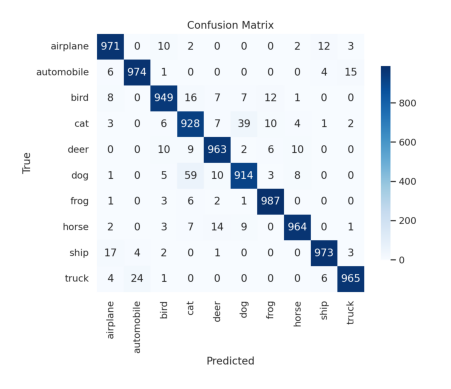

In [11]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("outputs/confusion_matrix.png")
plt.imshow(img)
plt.axis('off')
plt.show()


### 3. Affichage du leaderboard
Ce projet a permis de mettre en place un pipeline complet de classification d'images. Les expériences montrent l'importance du tuning des hyperparamètres (LR) et de la régularisation pour atteindre une performance > 90% sur ce dataset.

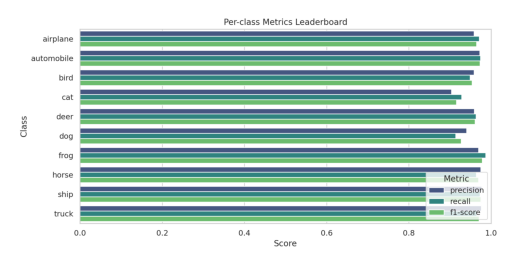

In [12]:
img = Image.open("outputs/leaderboard.png")
plt.imshow(img)
plt.axis('off')
plt.show()


### 4. Affichage des résultats en fonction des époques

In [13]:
import pandas as pd

df_logs = pd.read_csv("outputs/log.csv")
df_logs.head()


,epoch,train_loss,val_loss,val_acc
0,1,0.4352,0.2599,0.9100
1,2,0.2057,0.1897,0.9342
2,3,0.1290,0.1786,0.9398
3,4,0.0841,0.1422,0.9523
4,5,0.0602,0.1283,0.9588


### 5. Affichage des métriques du meilleur modèle par classe

In [14]:
df_per_class = pd.read_csv("outputs/per_class_metrics.csv")
df_per_class


,Unnamed: 0,precision,recall,f1-score,support
0,airplane,0.9585,0.971,0.9647,1000.0
1,automobile,0.9721,0.974,0.9730,1000.0
2,bird,0.9586,0.949,0.9538,1000.0
3,cat,0.9036,0.928,0.9156,1000.0
4,deer,0.9592,0.963,0.9611,1000.0
5,dog,0.9403,0.914,0.9270,1000.0
6,frog,0.9695,0.987,0.9782,1000.0
7,horse,0.9747,0.964,0.9693,1000.0
8,ship,0.9769,0.973,0.9749,1000.0
9,truck,0.9757,0.965,0.9703,1000.0


### 6. Évolution de la fonction de perte à l'entraînement et à la validation en fonction des époques

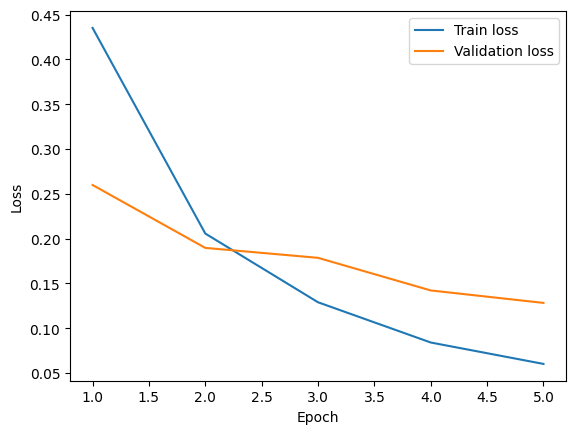

In [15]:
plt.plot(df_logs['epoch'], df_logs['train_loss'], label='Train loss')
plt.plot(df_logs['epoch'], df_logs['val_loss'], label='Validation loss')
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()


### 7. Affichage des métriques globales pour le meilleur modèle obtenu.

In [16]:
with open("outputs/eval.json") as f:
    eval_results = json.load(f)

eval_results


{'val_acc': 0.9587999582290649,
 'macro_precision': 0.9589186800180307,
 'macro_recall': 0.9588000000000001,
 'macro_f1': 0.9588033792839298,
 'weighted_precision': 0.9589186800180305,
 'weighted_recall': 0.9588,
 'weighted_f1': 0.9588033792839298,
 'accuracy': 0.9588,
 'num_samples': 10000,
 'classes': ['airplane',
  'automobile',
  'bird',
  'cat',
  'deer',
  'dog',
  'frog',
  'horse',
  'ship',
  'truck']}

### Conclusion

Ce projet a permis de mettre en place un pipeline complet de classification d'images. Les expériences montrent l'importance du tuning des hyperparamètres (LR) et de la régularisation pour atteindre une performance > 90% sur ce dataset.